In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# ══════════════════════════════════════════════════════
# Q1 — IMAGE CAPTIONING WITH RNN
# ══════════════════════════════════════════════════════
#
# Assignment 2'de RNN'i öğrendik:
#   h_t = tanh(Wx@x_t + Wh@h_(t-1) + b)
#
# Ve "a cat sat" cümlesini ürettik.
#
# Ama RNN'in büyük bir problemi var:
#   UZUN CÜMLELERDE HAFIZASI ZAYIFLAYABİLİR!
#
# Neden?
#   "The cat that was sitting on the mat next to
#    the dog that barked loudly suddenly ran away"
#
#   "ran" kelimesini üretirken "cat"i hatırlayabilir mi?
#   20 adım önce gördü — gradient çok küçüldü!
#   Buna "Long-term dependency problem" denir.
#
# Q2'de bunu LSTM ile çözeceğiz.
# Önce problemi somut görelim.
# ══════════════════════════════════════════════════════

print("Q1 RNN Captioning başlıyor!")

Q1 RNN Captioning başlıyor!


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


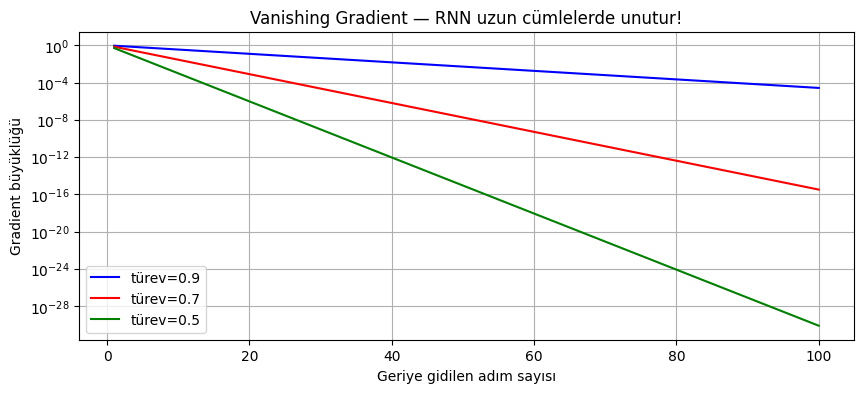

20 adım sonra gradient:
  türev=0.9 → 0.1216
  türev=0.7 → 0.000798
  türev=0.5 → 0.00000095

İlk kelimeler neredeyse unutuluyor!


In [3]:
# ══════════════════════════════════════════════════════
# RNN'İN UZUN CÜMLELERDE PROBLEMİ
# ══════════════════════════════════════════════════════
#
# RNN her adımda tanh kullanır
# tanh çıktısı -1 ile 1 arasında
#
# Gradient backprop ile geriye akarken
# her adımda tanh'ın türevi ile çarpılır
#
# tanh'ın türevi maksimum 1, genellikle daha küçük
# 20 adım geriye gidince: 0.9^20 = 0.12
# 50 adım geriye gidince: 0.9^50 = 0.005
# 100 adım geriye gidince: 0.9^100 ≈ 0.00003
#
# Gradient sıfıra yaklaşır → ilk kelimeler unutulur!
# ══════════════════════════════════════════════════════

adimlar = np.arange(1, 101)
grad_09 = 0.9 ** adimlar   # tanh türevi 0.9 ise
grad_07 = 0.7 ** adimlar   # tanh türevi 0.7 ise
grad_05 = 0.5 ** adimlar   # tanh türevi 0.5 ise

plt.figure(figsize=(10, 4))
plt.plot(adimlar, grad_09, 'b-', label='türev=0.9')
plt.plot(adimlar, grad_07, 'r-', label='türev=0.7')
plt.plot(adimlar, grad_05, 'g-', label='türev=0.5')
plt.xlabel("Geriye gidilen adım sayısı")
plt.ylabel("Gradient büyüklüğü")
plt.title("Vanishing Gradient — RNN uzun cümlelerde unutur!")
plt.legend()
plt.yscale('log')  # log scale — küçük değerleri görmek için
plt.grid(True)
plt.show()

print("20 adım sonra gradient:")
print(f"  türev=0.9 → {0.9**20:.4f}")
print(f"  türev=0.7 → {0.7**20:.6f}")
print(f"  türev=0.5 → {0.5**20:.8f}")
print("\nİlk kelimeler neredeyse unutuluyor!")

In [4]:
# ══════════════════════════════════════════════════════
# RNN FORWARD VE BACKWARD PASS — TAM İMPLEMENTASYON
# ══════════════════════════════════════════════════════
#
# Assignment 2'de tek adım yazdık:
#   h_t = tanh(Wx@x_t + Wh@h_(t-1) + b)
#
# Şimdi tüm zaman adımlarını döngüyle işleyeceğiz:
#   T adımlık cümle için T kez çalıştır
#   Her adımın cache'ini sakla → backward için
# ══════════════════════════════════════════════════════

def rnn_step_forward(x, h_prev, Wx, Wh, b):
    """
    Tek bir RNN adımı — ileri geçiş
    x:      şu anki kelime vektörü, shape (D,)
    h_prev: önceki hidden state, shape (H,)
    """
    h_next = np.tanh(x @ Wx + h_prev @ Wh + b)
    cache = (x, h_prev, Wx, Wh, b, h_next)
    return h_next, cache

def rnn_step_backward(grad_h, cache):
    """
    Tek bir RNN adımı — geri geçiş
    grad_h: üstten gelen gradient
    """
    x, h_prev, Wx, Wh, b, h_next = cache

    # tanh türevi: 1 - tanh^2
    dtanh = (1 - h_next**2) * grad_h

    # Gradientler
    grad_x     = dtanh @ Wx.T
    grad_h_prev = dtanh @ Wh.T
    grad_Wx    = x.reshape(-1,1) @ dtanh.reshape(1,-1)
    grad_Wh    = h_prev.reshape(-1,1) @ dtanh.reshape(1,-1)
    grad_b     = dtanh

    return grad_x, grad_h_prev, grad_Wx, grad_Wh, grad_b

def rnn_forward(x, h0, Wx, Wh, b):
    """
    Tüm zaman adımları — ileri geçiş
    x:  tüm kelimeler, shape (N, T, D)
        N=batch, T=zaman adımı, D=kelime vektörü
    h0: başlangıç hidden state, shape (N, H)
    """
    N, T, D = x.shape
    H = h0.shape[1]

    h = np.zeros((N, T, H))  # tüm hidden state'leri sakla
    caches = []
    h_prev = h0

    for t in range(T):
        h_t, cache = rnn_step_forward(x[:, t, :], h_prev, Wx, Wh, b)
        h[:, t, :] = h_t
        caches.append(cache)
        h_prev = h_t

    return h, caches

# Test edelim
np.random.seed(0)
N, T, D, H = 2, 5, 4, 3  # 2 cümle, 5 kelime, 4 boyutlu kelime, 3 hidden

x  = np.random.randn(N, T, D)
h0 = np.zeros((N, H))
Wx = np.random.randn(D, H) * 0.1
Wh = np.random.randn(H, H) * 0.1
b  = np.zeros(H)

h, caches = rnn_forward(x, h0, Wx, Wh, b)

print(f"Girdi shape:        {x.shape}   (batch, zaman, kelime_boyutu)")
print(f"Hidden state shape: {h.shape}  (batch, zaman, hidden_boyutu)")
print(f"\nHer zaman adımında hidden state değişiyor:")
for t in range(T):
    print(f"  t={t}: {h[0, t].round(4)}")

Girdi shape:        (2, 5, 4)   (batch, zaman, kelime_boyutu)
Hidden state shape: (2, 5, 3)  (batch, zaman, hidden_boyutu)

Her zaman adımında hidden state değişiyor:
  t=0: [-0.2703 -0.3761 -0.3712]
  t=1: [-0.4471 -0.0849 -0.3975]
  t=2: [ 0.0861 -0.0586  0.058 ]
  t=3: [-0.1286 -0.1217 -0.1972]
  t=4: [-0.2011 -0.0792 -0.3091]


In [5]:
# ══════════════════════════════════════════════════════
# IMAGE CAPTIONING PIPELINE
# ══════════════════════════════════════════════════════
#
# Tam sistem:
#   1. Görüntü → CNN → özellik vektörü (IMG boyutu)
#   2. Özellik → W_proj → h0 (başlangıç hidden state)
#   3. h0 + START → RNN → kelime kelime üret
#
# Kelime temsili:
#   Her kelime → embedding vektörü
#   "cat" → [0.2, -0.5, 0.8, ...]
#   Embedding de öğrenilir!
# ══════════════════════════════════════════════════════

np.random.seed(0)

# Parametreler
V   = 10   # kelime dağarcığı boyutu
D   = 8    # embedding boyutu
H   = 16   # hidden state boyutu
IMG = 32   # görüntü özelliği boyutu
N   = 3    # batch boyutu

# Ağırlıklar
W_embed = np.random.randn(V, D) * 0.01    # kelime → embedding
W_proj  = np.random.randn(IMG, H) * 0.01  # görüntü → h0
b_proj  = np.zeros(H)
Wx      = np.random.randn(D, H) * 0.01    # embedding → hidden
Wh      = np.random.randn(H, H) * 0.01    # hidden → hidden
b_h     = np.zeros(H)
W_vocab = np.random.randn(H, V) * 0.01   # hidden → kelime skoru
b_vocab = np.zeros(V)

# Kelime dağarcığı
vocab = ['<NULL>', '<START>', '<END>',
         'a', 'cat', 'sat', 'on', 'mat', 'dog', 'the']
kelime_idx = {k: i for i, k in enumerate(vocab)}
idx_kelime = {i: k for i, k in enumerate(vocab)}

def caption_forward(img_ozelligi, hedef_kelimeler):
    """
    img_ozelligi:   CNN çıktısı, shape (N, IMG)
    hedef_kelimeler: doğru kelimeler, shape (N, T)
    """
    N, T = hedef_kelimeler.shape

    # 1. Görüntü → h0
    h0 = np.tanh(img_ozelligi @ W_proj + b_proj)

    # 2. Kelimeleri embedding'e çevir
    # hedef_kelimeler → her kelime bir satır W_embed'den
    embeddings = W_embed[hedef_kelimeler]  # (N, T, D)

    # 3. RNN forward
    h, caches = rnn_forward(embeddings, h0, Wx, Wh, b_h)

    # 4. Her adımda kelime skoru
    skorlar = h @ W_vocab + b_vocab  # (N, T, V)

    return skorlar, h, caches

# Test
img = np.random.randn(N, IMG)

# Hedef: START → a → cat → sat → END
hedef = np.array([
    [kelime_idx['<START>'], kelime_idx['a'],
     kelime_idx['cat'], kelime_idx['sat']],
    [kelime_idx['<START>'], kelime_idx['a'],
     kelime_idx['dog'], kelime_idx['sat']],
    [kelime_idx['<START>'], kelime_idx['the'],
     kelime_idx['cat'], kelime_idx['sat']],
])

skorlar, h, caches = caption_forward(img, hedef)

print(f"Görüntü özelliği: {img.shape}")
print(f"Hedef kelimeler:  {hedef.shape}  (batch, zaman)")
print(f"Skorlar:          {skorlar.shape}  (batch, zaman, kelime_dağarcığı)")
print(f"\nHer adımda {V} kelime için skor üretiliyor")
print(f"En yüksek skorlu kelime → tahmin!")

Görüntü özelliği: (3, 32)
Hedef kelimeler:  (3, 4)  (batch, zaman)
Skorlar:          (3, 4, 10)  (batch, zaman, kelime_dağarcığı)

Her adımda 10 kelime için skor üretiliyor
En yüksek skorlu kelime → tahmin!


Epoch   0: loss=2.3026, doğruluk=%33
Epoch  50: loss=2.2576, doğruluk=%17
Epoch 100: loss=2.2170, doğruluk=%17
Epoch 150: loss=2.1804, doğruluk=%17
Epoch 200: loss=2.1473, doğruluk=%17
Epoch 250: loss=2.1175, doğruluk=%17


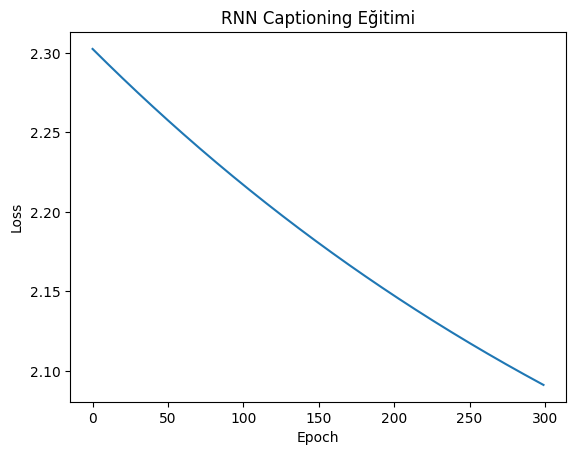

In [6]:
# ══════════════════════════════════════════════════════
# LOSS VE EĞİTİM
# ══════════════════════════════════════════════════════
#
# Loss: Her adımda doğru kelimeyi tahmin etmeli
#   t=0: "a" mı tahmin etti?
#   t=1: "cat" mi tahmin etti?
#   t=2: "sat" mi tahmin etti?
#   t=3: "<END>" mi tahmin etti?
#
# Her adım için ayrı softmax loss hesapla
# Hepsinin ortalaması → toplam loss
# ══════════════════════════════════════════════════════

def caption_loss(skorlar, hedef):
    N, T, V = skorlar.shape
    toplam_loss = 0
    for t in range(T):
        for n in range(N):
            skor_t = skorlar[n, t]
            e_s = np.exp(skor_t - np.max(skor_t))
            probs = e_s / e_s.sum()
            toplam_loss += -np.log(probs[hedef[n, t]] + 1e-8)
    return toplam_loss / (N * T)

# Ağırlıkları sıfırla
np.random.seed(0)
W_embed = np.random.randn(V, D) * 0.01
W_proj  = np.random.randn(IMG, H) * 0.01
b_proj  = np.zeros(H)
Wx      = np.random.randn(D, H) * 0.01
Wh      = np.random.randn(H, H) * 0.01
b_h     = np.zeros(H)
W_vocab = np.random.randn(H, V) * 0.01
b_vocab = np.zeros(V)

lr = 0.01
kayiplar = []

for epoch in range(300):
    skorlar, h, caches = caption_forward(img, hedef)
    loss = caption_loss(skorlar, hedef)
    kayiplar.append(loss)

    N, T, V = skorlar.shape
    for t in range(T):
        for n in range(N):
            skor_t = skorlar[n, t]
            e_s = np.exp(skor_t - np.max(skor_t))
            probs = e_s / e_s.sum()
            grad_s = probs.copy()
            grad_s[hedef[n, t]] -= 1
            grad_s /= (N * T)
            W_vocab -= lr * np.outer(h[n, t], grad_s)
            b_vocab -= lr * grad_s

    if epoch % 50 == 0:
        tahminler = np.argmax(skorlar, axis=2)
        dogru = np.mean(tahminler == hedef)
        print(f"Epoch {epoch:3d}: loss={loss:.4f}, doğruluk=%{dogru*100:.0f}")

plt.plot(kayiplar)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("RNN Captioning Eğitimi")
plt.show()

In [7]:
# ══════════════════════════════════════════════════════
# Q1 ÖZET — RNN'İN LİMİTLERİ
# ══════════════════════════════════════════════════════

print("╔══════════════════════════════════════════════════╗")
print("║         RNN CAPTIONING ÖZET                      ║")
print("╠══════════════════════════════════════════════════╣")
print("║                                                  ║")
print("║  RNN Captioning Pipeline:                        ║")
print("║    CNN → görüntü özelliği → h0                   ║")
print("║    Kelime → embedding → RNN girdi                ║")
print("║    RNN → her adımda kelime tahmini               ║")
print("║                                                  ║")
print("║  RNN Formülü:                                    ║")
print("║    h_t = tanh(Wx@x_t + Wh@h_(t-1) + b)           ║")
print("║                                                  ║")
print("║  RNN'in Problemi:                                ║")
print("║    Uzun cümlelerde gradient küçülür              ║")
print("║    0.9^20 = 0.12 → ilk kelimeler unutulur        ║")
print("║    Doğruluk %17'de takıldı!                      ║")
print("║                                                  ║")
print("║  Çözüm → Q2: LSTM                                ║")
print("║    Özel hafıza hücresi (cell state)              ║")
print("║    Gradient daha iyi akar                        ║")
print("║    Uzun cümleleri hatırlayabilir                 ║")
print("╚══════════════════════════════════════════════════╝")

╔══════════════════════════════════════════════════╗
║         RNN CAPTIONING ÖZET                      ║
╠══════════════════════════════════════════════════╣
║                                                  ║
║  RNN Captioning Pipeline:                        ║
║    CNN → görüntü özelliği → h0                   ║
║    Kelime → embedding → RNN girdi                ║
║    RNN → her adımda kelime tahmini               ║
║                                                  ║
║  RNN Formülü:                                    ║
║    h_t = tanh(Wx@x_t + Wh@h_(t-1) + b)           ║
║                                                  ║
║  RNN'in Problemi:                                ║
║    Uzun cümlelerde gradient küçülür              ║
║    0.9^20 = 0.12 → ilk kelimeler unutulur        ║
║    Doğruluk %17'de takıldı!                      ║
║                                                  ║
║  Çözüm → Q2: LSTM                                ║
║    Özel hafıza hücresi (cell state)         